In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

from scipy import stats
from scipy.stats import sem
from scipy.stats import shapiro
from scipy.stats import normaltest
from scipy.stats import ttest_rel,ttest_ind,wilcoxon
import json
import statsmodels.api as sm
import pylab as py

from tqdm import trange

import sys
sys.path.append('/Users/dbao/Downloads/research/rc_scripts/submission/analysis')
# import final_analysis.plot_helper.format

In [2]:
from process_helper import *
from plot_helper import *

save_mode = ".pdf"
font_size = 8

In [3]:
# import rpy2
# import rpy2.situation as r_situation
# print(r_situation.get_r_home())

# !python -m rpy2.situation
# %load_ext rpy2.ipython

%load_ext rpy2.ipython

from rpy2.robjects.packages import importr
# import R's "base" package
lme4 = importr('lme4')
mass = importr('MASS')
rcompanion = importr('rcompanion')

/Users/dbao/opt/anaconda3/envs/road/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:14: FutureWarning: pandas.core.index is deprecated and will be removed in a future version. The public classes are available in the top-level namespace.
  from pandas.core.index import Index as PandasIndex


In [4]:
home_dir = '/Users/dbao/Library/CloudStorage/GoogleDrive-sherrydbao@gmail.com/My Drive/road_construction_data/data/2022_online/'
map_dir = 'active_map/'
data_dir  = 'data/preprocessed'

out_dir = home_dir + 'figures/figures_final/'
R_out_dir = home_dir + 'R_analysis_data/'

In [5]:
data_choice_level = pd.read_csv(R_out_dir +  'choice_level/choicelevel_data.csv')
data_choice_level = df_choice_add_features(data_choice_level)

data_puzzle_level = pd.read_csv(R_out_dir +  'data.csv')
data_puzzle_level = df_map_add_features(data_puzzle_level, data_choice_level)
puzzleID_order_data = data_puzzle_level.sort_values(["subjects","puzzleID"])


single_condition_data = puzzleID_order_data[puzzleID_order_data['condition']==1].copy()
single_condition_data = single_condition_data.reset_index()
sc_data_choice_level = data_choice_level[data_choice_level['condition']==1].reset_index()

In [6]:
with open(home_dir + map_dir + '/basicMap.json', 'r') as file:
    map = json.load(file)

# *Figure 1a: demo

In [7]:
# check which sub and map has only one single undo 
subs = []
maps = []
undo_level = data_choice_level[data_choice_level['condition']==1].copy().reset_index()
basic_level = data_choice_level[data_choice_level['condition']==0].copy().reset_index()

for sub in range(100):
    dat_sbj_undo = undo_level[undo_level['subjects']==sub].sort_values(["puzzleID","index"])
    for pzi in np.unique(dat_sbj_undo['puzzleID']):
        dat_sbj_undo_pzi = dat_sbj_undo[dat_sbj_undo['puzzleID'] == pzi].reset_index()
        if dat_sbj_undo_pzi['firstUndo'].sum() == 1:
            subs.append(sub)
            maps.append(pzi)
for i in range(len(subs)):
    print(f"Subject: {subs[i]}, Map: {maps[i]}")

Subject: 0, Map: 0
Subject: 0, Map: 2
Subject: 0, Map: 14
Subject: 0, Map: 18
Subject: 0, Map: 23
Subject: 0, Map: 28
Subject: 1, Map: 2
Subject: 1, Map: 3
Subject: 1, Map: 7
Subject: 1, Map: 9
Subject: 1, Map: 10
Subject: 1, Map: 12
Subject: 1, Map: 13
Subject: 1, Map: 14
Subject: 1, Map: 15
Subject: 1, Map: 16
Subject: 1, Map: 20
Subject: 1, Map: 25
Subject: 1, Map: 30
Subject: 1, Map: 33
Subject: 1, Map: 34
Subject: 1, Map: 36
Subject: 1, Map: 37
Subject: 1, Map: 38
Subject: 1, Map: 42
Subject: 1, Map: 44
Subject: 1, Map: 45
Subject: 2, Map: 2
Subject: 2, Map: 3
Subject: 2, Map: 8
Subject: 2, Map: 11
Subject: 2, Map: 12
Subject: 2, Map: 17
Subject: 2, Map: 25
Subject: 2, Map: 32
Subject: 2, Map: 34
Subject: 2, Map: 35
Subject: 3, Map: 6
Subject: 3, Map: 12
Subject: 3, Map: 26
Subject: 3, Map: 28
Subject: 3, Map: 32
Subject: 3, Map: 41
Subject: 4, Map: 6
Subject: 4, Map: 8
Subject: 4, Map: 9
Subject: 4, Map: 11
Subject: 4, Map: 12
Subject: 4, Map: 14
Subject: 4, Map: 15
Subject: 4, M

In [8]:
def find_sublist_index(target, list_of_sublists):
    try:
        return list_of_sublists.index(target)
    except ValueError:
        return -1  # returns -1 if the sublist is not found

In [9]:
# sub = 1
# sub = 4
sub = 0
pzi = 0
# pzi = 9

# compariosn between performance
undo_level = data_choice_level[data_choice_level['condition']==1].copy().reset_index()
basic_level = data_choice_level[data_choice_level['condition']==0].copy().reset_index()

dat_sbj_undo  = undo_level[undo_level['subjects']==sub].sort_values(["puzzleID","index"])
# dat_sbj_basic  = basic_level[basic_level['subjects']==sub].sort_values(["puzzleID","index"])
TS = map[pzi]

dat_sbj_undo_pzi = dat_sbj_undo[dat_sbj_undo['puzzleID'] == pzi].reset_index()

print(dat_sbj_undo_pzi['path'])

# get distance from TS['xy'][0] to TS['xy'][1:]
start = np.array(TS['xy'][0])
distance = [np.sum(np.sqrt((start - np.array(node))**2)) for node in TS['xy'][1:]]

TS = map[pzi]

R = 300.0

rem_xy = TS['xy'].copy()
# pop the current one
curr_xy = rem_xy.pop(0)
cts_in_order = []
cts_in_order.append(curr_xy)
cts_idx_in_order = [find_sublist_index(curr_xy, TS['xy'])]

paths = [] 
# index of first undo == 1 to numbers
fundo_indexes = dat_sbj_undo_pzi.index[dat_sbj_undo_pzi['firstUndo'] == 1].tolist()
lundo_indexes = dat_sbj_undo_pzi.index[dat_sbj_undo_pzi['lastUndo'] == 1].tolist()
dosrt_indexes = np.array([-1, *lundo_indexes])
dosrt_indexes = dosrt_indexes + 1
doend_indexes = np.array([*fundo_indexes, len(dat_sbj_undo_pzi)])


for i in range(len(dat_sbj_undo_pzi)-1):
    paths.append([TS['xy'][dat_sbj_undo_pzi['choice'][i]], TS['xy'][dat_sbj_undo_pzi['choice'][i+1]]])
print(paths)

first_do_connected = []
for i in range(dosrt_indexes[0], doend_indexes[0]):
    first_do_connected.append(dat_sbj_undo_pzi['choice'].iloc[i])
print(first_do_connected)
# first do sequence
print(dat_sbj_undo_pzi['path'].iloc[dosrt_indexes[0]:doend_indexes[0]])

first_undo_connected = []
for i in range(fundo_indexes[0]-1, lundo_indexes[0]+1):
    first_undo_connected.append(dat_sbj_undo_pzi['choice'].iloc[i])
print(first_undo_connected)
# if last of first undo is not 0, then append to first_undo_alrdy

# first undo sequence
print(dat_sbj_undo_pzi['path'].iloc[fundo_indexes[0]-1:lundo_indexes[0]+1])


0                                [0]
1                            [0, 20]
2                        [0, 20, 28]
3                     [0, 20, 28, 5]
4                  [0, 20, 28, 5, 4]
5              [0, 20, 28, 5, 4, 24]
6          [0, 20, 28, 5, 4, 24, 26]
7      [0, 20, 28, 5, 4, 24, 26, 12]
8          [0, 20, 28, 5, 4, 24, 26]
9              [0, 20, 28, 5, 4, 24]
10                 [0, 20, 28, 5, 4]
11                    [0, 20, 28, 5]
12                       [0, 20, 28]
13                           [0, 20]
14                        [0, 20, 5]
15                     [0, 20, 5, 4]
16                 [0, 20, 5, 4, 24]
17             [0, 20, 5, 4, 24, 15]
18          [0, 20, 5, 4, 24, 15, 7]
19       [0, 20, 5, 4, 24, 15, 7, 8]
20    [0, 20, 5, 4, 24, 15, 7, 8, 3]
21    [0, 20, 5, 4, 24, 15, 7, 8, 3]
Name: path, dtype: object
[[[24, 135], [-41, 81]], [[-41, 81], [-5, 34]], [[-5, 34], [-46, 19]], [[-46, 19], [-44, -6]], [[-44, -6], [-53, -13]], [[-53, -13], [-36, -15]], [[-36, -15], [

In [10]:
print(first_do_connected)
path_do_connected = []
for i in range(len(first_do_connected)-1):
    path_do_connected.append([TS['xy'][first_do_connected[i]], TS['xy'][first_do_connected[i+1]]])
print(path_do_connected)

[0, 20, 28, 5, 4, 24, 26, 12]
[[[24, 135], [-41, 81]], [[-41, 81], [-5, 34]], [[-5, 34], [-46, 19]], [[-46, 19], [-44, -6]], [[-44, -6], [-53, -13]], [[-53, -13], [-36, -15]], [[-36, -15], [-1, -19]]]


In [11]:
fig1a_data = {}

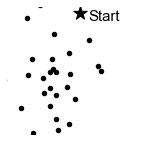

In [12]:
# figure that shows how do improves for greedy policy by gradients of red colors that shows how they improved from start to the end
%matplotlib inline
fig, ax = plt.subplots(figsize=(2,2))

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams.update({'font.size': font_size})

# plo the map
for i in range(len(TS['xy'])):
    ax.scatter(TS['xy'][i][0], TS['xy'][i][1], color='black', s=20)
ax.annotate('Start', (TS['xy'][0][0]+20, TS['xy'][0][1]-20), fontsize=15, c='k')
    
ax.scatter(TS['xy'][0][0], TS['xy'][0][1], color='k', s=200, marker='*', alpha=1)

# grid off
ax.grid(False)

# remove all borders
for spine in plt.gca().spines.values():
    spine.set_visible(False)

    
# x lim y lim
ax.set_xlim([-160, 160])
ax.set_ylim([-170, 150])

# x ticks and y ticks
ax.set_xticks([])
ax.set_yticks([])

# make axis equal
ax.set_aspect('equal') 

fig1a_data['0'] = {'x': TS['xy'][0][0], 'y': TS['xy'][0][1]}
plt.tight_layout()
plt.savefig(out_dir + 'do_0' + save_mode, bbox_inches='tight', pad_inches=0.1)

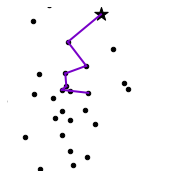

In [13]:
# figure that shows how do improves for greedy policy by gradients of red colors that shows how they improved from start to the end
%matplotlib inline
fig, ax = plt.subplots(figsize=(3,3))
mpl.rcParams.update({'font.size': font_size})

# green_values = [200, 160, 120, 80, 40]
# green_values = [100, 125, 150, 175, 200]
green_values = np.linspace(200, 200, len(path_do_connected)).astype(int)
colors = [f'#{0:02x}{v:02x}{0:02x}' for v in green_values]

purple_values = np.linspace(200, 200, len(path_do_connected)).astype(int)
colors = [(v / 255.0 * 0.6, 0.0, v / 255.0) for v in purple_values]  # Purple tones

ax.set_aspect('equal') 
# plot the optimal path
for i in range(len(path_do_connected)):
    ax.plot([path_do_connected[i][0][0], path_do_connected[i][1][0]], [path_do_connected[i][0][1], path_do_connected[i][1][1]], color=colors[i], linewidth=2, alpha=1)


# plot the map
for i in range(len(TS['xy'])):
    ax.scatter(TS['xy'][i][0], TS['xy'][i][1], color='black', s=20)
# ax.annotate('Start', (TS['xy'][0][0]+20, TS['xy'][0][1]-15), fontsize=18, c='r')
    
ax.scatter(TS['xy'][0][0], TS['xy'][0][1], color='k', s=200, marker='*', alpha=1)

# grid off
ax.grid(False)

# remove all borders
for spine in plt.gca().spines.values():
    spine.set_visible(False)

    
# x lim y lim
ax.set_xlim([-160, 160])
ax.set_ylim([-170, 150])

# x ticks and y ticks
ax.set_xticks([])
ax.set_yticks([])

fig1a_data['1'] = {'x': TS['xy'][0][0], 'y': TS['xy'][0][1], 'path_do_connected': deepcopy(path_do_connected), 'colors': deepcopy(colors)}

# make axis equal
plt.savefig(out_dir + 'do_1' + save_mode, bbox_inches='tight', pad_inches=0.1)

In [14]:
print(first_undo_connected)
path_undo_connected = []
for i in range(len(first_undo_connected)-1):
    path_undo_connected.append([TS['xy'][first_undo_connected[i]], TS['xy'][first_undo_connected[i+1]]])
print(path_undo_connected)

print(first_do_connected)
# difference between first_do_connected and first_undo_connected
first_do_remaining = [i for i in first_do_connected if i not in first_undo_connected]
first_do_remaining.append(first_undo_connected[-1])
print(first_do_remaining)
path_do_remaining = []
for i in range(len(first_do_remaining)-1):
    path_do_remaining.append([TS['xy'][first_do_remaining[i]], TS['xy'][first_do_remaining[i+1]]])

[12, 26, 24, 4, 5, 28, 20]
[[[-1, -19], [-36, -15]], [[-36, -15], [-53, -13]], [[-53, -13], [-44, -6]], [[-44, -6], [-46, 19]], [[-46, 19], [-5, 34]], [[-5, 34], [-41, 81]]]
[0, 20, 28, 5, 4, 24, 26, 12]
[0, 20]


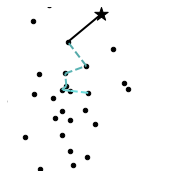

In [15]:
# figure that shows how do improves for greedy policy by gradients of red colors that shows how they improved from start to the end
%matplotlib inline
fig, ax = plt.subplots(figsize=(3,3))
mpl.rcParams.update({'font.size': font_size})
# mpl.rcParams['font.family'] = 'Arial'
# mpl.rcParams['font.size'] = 15

# orange_values = np.linspace(250, 250, len(path_undo_connected)).astype(int)
# orange_values = orange_values[::-1]
# colors = [(v / 255.0, v / 255.0 * 0.5, 0.0) for v in orange_values]

mint_values = np.linspace(220, 170, len(path_undo_connected)).astype(int)
colors = [(v / 255.0 * 0.5, v / 255.0, v / 255.0 ) for v in mint_values]  # Softer mint tone


ax.set_aspect('equal') 
# plot the optimal path
for i in range(len(path_undo_connected)):
    ax.plot([path_undo_connected[i][0][0], path_undo_connected[i][1][0]],
            [path_undo_connected[i][0][1], path_undo_connected[i][1][1]], color=colors[i], linewidth=2, alpha=1, linestyle='--')
for i in range(len(path_do_remaining)):
    ax.plot([path_do_remaining[i][0][0], path_do_remaining[i][1][0]],
            [path_do_remaining[i][0][1], path_do_remaining[i][1][1]], color='k', linewidth=2, alpha=1)


# plot the map
for i in range(len(TS['xy'])):
    ax.scatter(TS['xy'][i][0], TS['xy'][i][1], color='black', s=20)
# ax.annotate('Start', (TS['xy'][0][0]+20, TS['xy'][0][1]-15), fontsize=18, c='r')
    
ax.scatter(TS['xy'][0][0], TS['xy'][0][1], color='k', s=200, marker='*', alpha=1)

# grid off
ax.grid(False)

# remove all borders
for spine in plt.gca().spines.values():
    spine.set_visible(False)

    
# x lim y lim
ax.set_xlim([-160, 160])
ax.set_ylim([-170, 150])


# x ticks and y ticks
ax.set_xticks([])
ax.set_yticks([])

fig1a_data['2'] = {'x': TS['xy'][0][0], 'y': TS['xy'][0][1], 'path_undo_connected': deepcopy(path_undo_connected), 'path_do_remaining': deepcopy(path_do_remaining), 'colors': deepcopy(colors)}

# make axis equal
plt.savefig(out_dir + 'undo_1' + save_mode, bbox_inches='tight', pad_inches=0.1)

In [16]:
second_do_connected = [first_do_remaining[-1]]
for i in range(dosrt_indexes[1], doend_indexes[1]):
    second_do_connected.append(dat_sbj_undo_pzi['choice'].iloc[i])
second_do_connected = second_do_connected[:-1]
print(second_do_connected)

[20, 5, 4, 24, 15, 7, 8, 3]


In [17]:
print(second_do_connected)
path_do_connected = []
for i in range(len(second_do_connected)-1):
    path_do_connected.append([TS['xy'][second_do_connected[i]], TS['xy'][second_do_connected[i+1]]])
print(path_do_connected)

[20, 5, 4, 24, 15, 7, 8, 3]
[[[-41, 81], [-46, 19]], [[-46, 19], [-44, -6]], [[-44, -6], [-53, -13]], [[-53, -13], [-70, -29]], [[-70, -29], [-53, -55]], [[-53, -55], [-67, -68]], [[-67, -68], [-37, -73]]]


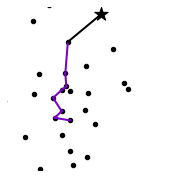

In [18]:
# figure that shows how do improves for greedy policy by gradients of red colors that shows how they improved from start to the end
%matplotlib inline
fig, ax = plt.subplots(figsize=(3,3))

# mpl.rcParams['font.family'] = 'Arial'
# mpl.rcParams['font.size'] = 15


# green_values = [200, 160, 120, 80, 40]
green_values = np.linspace(200, 200, len(path_do_connected)).tolist()
colors = [f'#{0:02x}{int(v):02x}{0:02x}' for v in green_values]

purple_values = np.linspace(200, 200, len(path_do_connected)).astype(int)
colors = [(v / 255.0 * 0.6, 0.0, v / 255.0) for v in purple_values]  # Purple tones

# # reverse order
# colors = colors[::-1]

# yellow_values = np.linspace(230, 220, len(path_do_connected)).astype(int)  # Light to darker yellow
# colors = [(v / 255.0, v / 255.0, 0.0) for v in yellow_values]  # RGB format

# colors = [(v / 255.0, v / 255.0 * 0.5, 0.0) for v in green_values]

ax.set_aspect('equal') 
# plot the optimal path
for i in range(len(path_do_connected)):
    ax.plot([path_do_connected[i][0][0], path_do_connected[i][1][0]], [path_do_connected[i][0][1], path_do_connected[i][1][1]], color=colors[i], linewidth=2, alpha=1)
for i in range(len(path_do_remaining)):
    ax.plot([path_do_remaining[i][0][0], path_do_remaining[i][1][0]], [path_do_remaining[i][0][1], path_do_remaining[i][1][1]], color='k', linewidth=2, alpha=1)

# plot the map
for i in range(len(TS['xy'])):
    ax.scatter(TS['xy'][i][0], TS['xy'][i][1], color='black', s=20)
# ax.annotate('Start', (TS['xy'][0][0]+20, TS['xy'][0][1]-15), fontsize=18, c='r')
    
ax.scatter(TS['xy'][0][0], TS['xy'][0][1], color='k', s=200, marker='*', alpha=1)

# grid off
ax.grid(False)

# remove all borders
for spine in plt.gca().spines.values():
    spine.set_visible(False)

    
# x lim y lim
ax.set_xlim([-160, 160])
ax.set_ylim([-170, 150])

# x ticks and y ticks
ax.set_xticks([])
ax.set_yticks([])

fig1a_data['3'] = {'x': TS['xy'][0][0], 'y': TS['xy'][0][1], 'path_do_connected': deepcopy(path_do_connected), 'path_do_remaining': deepcopy(path_do_remaining), 'colors': deepcopy(colors)}

# make axis equal
plt.savefig(out_dir + 'do_2' + save_mode, bbox_inches='tight', pad_inches=0.1)

In [19]:
submit_do = [*first_do_remaining]
# append second_do_connected to submit_do
submit_do += second_do_connected[1:]
print(submit_do)

path_submit = []
for i in range(len(submit_do)-1):
    path_submit.append([TS['xy'][submit_do[i]], TS['xy'][submit_do[i+1]]])
    


[0, 20, 5, 4, 24, 15, 7, 8, 3]


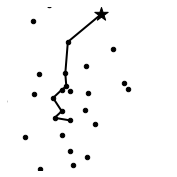

In [20]:
# figure that shows how do improves for greedy policy by gradients of red colors that shows how they improved from start to the end
%matplotlib inline
fig, ax = plt.subplots(figsize=(3,3))

# mpl.rcParams['font.family'] = 'Arial'
# mpl.rcParams['font.size'] = 15


# green_values = [200, 160, 120, 80, 40]
green_values = np.linspace(100, 200, len(path_do_connected)).tolist()
colors = [f'#{0:02x}{int(v):02x}{0:02x}' for v in green_values]
# colors = [(v / 255.0, v / 255.0 * 0.5, 0.0) for v in green_values]

ax.set_aspect('equal') 
# plot the optimal path
for i in range(len(path_submit)):
    ax.plot([path_submit[i][0][0], path_submit[i][1][0]], [path_submit[i][0][1], path_submit[i][1][1]], color='k', linewidth=2, alpha=1)

# plot the map
for i in range(len(TS['xy'])):
    ax.scatter(TS['xy'][i][0], TS['xy'][i][1], color='black', s=20)
# ax.annotate('Start', (TS['xy'][0][0]+20, TS['xy'][0][1]-15), fontsize=18, c='r')
    
ax.scatter(TS['xy'][0][0], TS['xy'][0][1], color='k', s=200, marker='*', alpha=1)

# grid off
ax.grid(False)

# remove all borders
for spine in plt.gca().spines.values():
    spine.set_visible(False)

    
# x lim y lim
ax.set_xlim([-160, 160])
ax.set_ylim([-170, 150])


# x ticks and y ticks
ax.set_xticks([])
ax.set_yticks([])

fig1a_data['4'] = {'x': TS['xy'][0][0], 'y': TS['xy'][0][1], 'path_submit': deepcopy(path_submit), 'colors': deepcopy(colors)}

# make axis equal
plt.savefig(out_dir + 'submit_2' + save_mode, bbox_inches='tight', pad_inches=0.1)

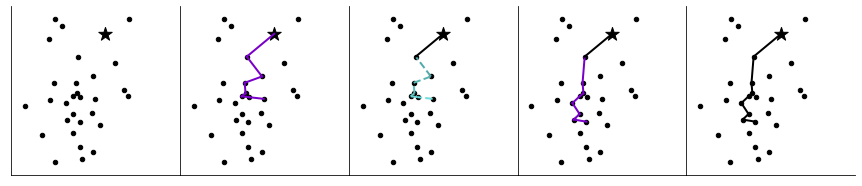

In [21]:
# combine the figures above to make a single figure
# load fig from fig1a_data and plot on the first subplot in 5 columns
%matplotlib inline
fig, ax = plt.subplots(figsize=(12.4,3), ncols=5)
mpl.rcParams.update({'font.size': font_size})
# tight layout with no gap between the subplots AND no space around the figure
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
plt.margins(0)

# mpl.rcParams['font.family'] = 'Arial'
# mpl.rcParams['font.size'] = 15

# plot the map from fig1a_data
for i in range(5):
    x = fig1a_data[str(i)]['x']
    y = fig1a_data[str(i)]['y']
    
    for j in range(len(TS['xy'])):
        ax[i].scatter(TS['xy'][j][0], TS['xy'][j][1], color='black', s=20)
    # ax[i].annotate('Start', (TS['xy'][0][0]+20, TS['xy'][0][1]-20), fontsize=14, c='k')
    
    # check if fig1a_data has colors as key
    if 'colors' in fig1a_data[str(i)].keys():
        colors = fig1a_data[str(i)]['colors']
    ax[i].scatter(x, y, color='k', s=200, marker='*', alpha=1)
    if i ==1:
        path_do_connected = fig1a_data[str(i)]['path_do_connected']
        for j in range(len(path_do_connected)):
            ax[i].plot([path_do_connected[j][0][0], path_do_connected[j][1][0]], [path_do_connected[j][0][1], path_do_connected[j][1][1]], color=colors[j], linewidth=2, alpha=1)
    elif i ==2:
        path_undo_connected = fig1a_data[str(i)]['path_undo_connected']
        for j in range(len(path_undo_connected)):
            ax[i].plot([path_undo_connected[j][0][0], path_undo_connected[j][1][0]], [path_undo_connected[j][0][1], path_undo_connected[j][1][1]], color=colors[j], linewidth=2, alpha=1, linestyle='--')
        path_do_remaining = fig1a_data[str(i)]['path_do_remaining']
        for j in range(len(path_do_remaining)):
            ax[i].plot([path_do_remaining[j][0][0], path_do_remaining[j][1][0]], [path_do_remaining[j][0][1], path_do_remaining[j][1][1]], color='k', linewidth=2, alpha=1)
    elif i ==3:
        path_do_connected = fig1a_data[str(i)]['path_do_connected']
        for j in range(len(path_do_connected)):
            ax[i].plot([path_do_connected[j][0][0], path_do_connected[j][1][0]], [path_do_connected[j][0][1], path_do_connected[j][1][1]], color=colors[j], linewidth=2, alpha=1)
        path_do_remaining = fig1a_data[str(i)]['path_do_remaining']
        for j in range(len(path_do_remaining)):
            ax[i].plot([path_do_remaining[j][0][0], path_do_remaining[j][1][0]], [path_do_remaining[j][0][1], path_do_remaining[j][1][1]], color='k', linewidth=2, alpha=1)
    elif i ==4:
        path_submit = fig1a_data[str(i)]['path_submit']
        for j in range(len(path_submit)):
            ax[i].plot([path_submit[j][0][0], path_submit[j][1][0]], [path_submit[j][0][1], path_submit[j][1][1]], color='k', linewidth=2, alpha=1)
    # grid off
    ax[i].grid(False)
    
    # remove all borders
    # for spine in ax[i].spines.values():
        # spine.set_visible(False)
        
    # x lim y lim
    ax[i].set_xlim([-200, 200])
    ax[i].set_ylim([-200, 200])
    
    # x ticks and y ticks
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
    # make axis equal
    ax[i].set_aspect('equal')
    
# ax[5].set_position([0.89, 0.05, 0.2, 0.85])

plt.savefig(out_dir + 'do_submit' + save_mode, bbox_inches='tight', pad_inches=0.1)

# *Figure 2: Comparison between conditions


In [22]:
figsize = 2.4
poz = 2

In [23]:
import matplotlib
import plot_helper.format

In [24]:
# compariosn between performance
undo_level = data_choice_level[data_choice_level['condition']==1].copy().reset_index()
basic_level = data_choice_level[data_choice_level['condition']==0].copy().reset_index()

error_magnitude = []
error_magnitude_mean = []
error_magnitude_all = []
error_magnitude_firstMove_mean = []

error_magnitude_mean_didnotundo = []
error_magnitude_mean_didundo = []

cum_error_UA_UNA = []
first_error_UA_UNA = []
first_rt_UA_UNA = []

optimality_firstmove = []

greedy_action = []
error_action = []
leftover = []

num_undo_per_mas = []
total_RT_per_mas = []
total_RT_per_mas_undoallowed = []
cumul_error_mag_per_mas = []

for sub in range(100):

    dat_sbj  = sc_data_choice_level[sc_data_choice_level['subjects']==sub].sort_values(["puzzleID","index"])
    dat_sbj_undo  = undo_level[undo_level['subjects']==sub].sort_values(["puzzleID","index"])
    dat_sbj_basic  = basic_level[basic_level['subjects']==sub].sort_values(["puzzleID","index"])

    error_magnitude_puzzle = []
    error_magnitude_firstMove_puzzle = []

    error_magnitude_mean_didnotundo_puzzle = []
    error_magnitude_mean_didundo_puzzle = []

    optimality_firstmove_puzzle = []

    greedy_action_puzzle = []
    error_action_puzzle = []
    leftover_puzzle = []

    cum_error_UA_UNA_puzzle = []
    first_error_UA_UNA_puzzle = []
    first_rt_UA_UNA_puzzle = []

    num_undo_per_mas_puzzle = []
    total_RT_per_mas_puzzle = []

    total_RT_per_mas_undoallowed_puzzle = []

    cumul_error_mag_per_mas_puzzle = []

    for pzi in np.unique(sc_data_choice_level['puzzleID']):

        TS = map[pzi]

        dat_sbj_pzi = dat_sbj[dat_sbj['puzzleID'] == pzi].reset_index()
        dat_sbj_undo_pzi = dat_sbj_undo[dat_sbj_undo['puzzleID'] == pzi].reset_index()
        dat_sbj_basic_pzi = dat_sbj_basic[dat_sbj_basic['puzzleID'] == pzi].reset_index()

        error_magnitude_puzzle.append([np.array(dat_sbj_undo_pzi['currMas'])[-1]-np.array(dat_sbj_undo_pzi['currMas'])[0],
                                  np.array(dat_sbj_basic_pzi['currMas'])[-1]-np.array(dat_sbj_basic_pzi['currMas'])[0]])
        error_magnitude_firstMove_puzzle.append([np.array(dat_sbj_undo_pzi['currMas'])[1]-np.array(dat_sbj_undo_pzi['currMas'])[0],
                                  np.array(dat_sbj_basic_pzi['currMas'])[1]-np.array(dat_sbj_basic_pzi['currMas'])[0]])

        # check if dat_sbj_undo_pzi['undo'].sum() is 0 or not
        if dat_sbj_undo_pzi['undo'].sum() == 0:
            error_magnitude_mean_didnotundo_puzzle.append([np.array(dat_sbj_undo_pzi['currMas'])[-1]-np.array(dat_sbj_undo_pzi['currMas'])[0],
                                                           np.array(dat_sbj_basic_pzi['currMas'])[-1]-np.array(dat_sbj_basic_pzi['currMas'])[0]])
        else:
            error_magnitude_mean_didundo_puzzle.append([np.array(dat_sbj_undo_pzi['currMas'])[-1]-np.array(dat_sbj_undo_pzi['currMas'])[0],
                                                        np.array(dat_sbj_basic_pzi['currMas'])[-1]-np.array(dat_sbj_basic_pzi['currMas'])[0]])

        optimality_firstmove_puzzle.append([dat_sbj_undo_pzi['currMas'][1]-dat_sbj_undo_pzi['currMas'][0],
                                            dat_sbj_basic_pzi['currMas'][1]-dat_sbj_basic_pzi['currMas'][0]])

        # get distance from TS['xy'][0] to TS['xy'][1:]
        start = np.array(TS['xy'][0])
        # distance = [np.sum(np.sqrt((start - np.array(node))**2)) for node in TS['xy'][1:]]
        distance = [np.sum(np.sqrt((start - np.array(node))**2)) for node in TS['xy']]

        # find the index that is second shortest distance because the first shortest is goint back to itself
        idx = np.argsort(distance)[1]

        # get proportion of data_sbj_undo_pzi['choice'][1] == idx
        greedy_action_puzzle.append([np.double(dat_sbj_undo_pzi['choice'][1] == idx),
                                     np.double(dat_sbj_basic_pzi['choice'][1] == idx)])

        # get proportion of data_sbj_undo_pzi['currMas'][1] is smaller than data_sbj_undo_pzi['currMas'][0]
        error_action_puzzle.append([np.double(dat_sbj_undo_pzi['currMas'][1] < dat_sbj_undo_pzi['currMas'][0]),
                                    np.double(dat_sbj_basic_pzi['currMas'][1] < dat_sbj_basic_pzi['currMas'][0])])
        
        
        cum_error_UA_UNA_puzzle.append([np.array(dat_sbj_undo_pzi['currMas'])[-1]-np.array(dat_sbj_undo_pzi['currMas'])[0],
                                        np.array(dat_sbj_basic_pzi['currMas'])[-1]-np.array(dat_sbj_basic_pzi['currMas'])[0]])
        first_error_UA_UNA_puzzle.append([np.array(dat_sbj_undo_pzi['currMas'])[1]-np.array(dat_sbj_undo_pzi['currMas'])[0],
                                        np.array(dat_sbj_basic_pzi['currMas'])[1]-np.array(dat_sbj_basic_pzi['currMas'])[0]])
        first_rt_UA_UNA_puzzle.append([np.array(dat_sbj_undo_pzi['RT'])[1], np.array(dat_sbj_basic_pzi['RT'])[1]])

        leftover_puzzle.append([np.array(dat_sbj_undo_pzi['leftover'])[-1], np.array(dat_sbj_basic_pzi['leftover'])[-1]])

        # append number of undos and puzzle MAS
        num_undo_per_mas_puzzle.append([np.array(dat_sbj_undo_pzi['undo']).sum(), dat_sbj_undo_pzi['currMas'][0]])
        total_RT_per_mas_puzzle.append([np.array(dat_sbj_basic_pzi['RT'][1:]).sum(), dat_sbj_basic_pzi['currMas'][0]])
        total_RT_per_mas_undoallowed_puzzle.append([np.array(dat_sbj_undo_pzi['RT'][1:]).sum(), dat_sbj_undo_pzi['currMas'][0]])

        # append cumulative error magnitude
        cumul_error_mag_per_mas_puzzle.append([np.array(dat_sbj_undo_pzi['currMas'])[-1]-np.array(dat_sbj_undo_pzi['currMas'])[0],
                                               np.array(dat_sbj_basic_pzi['currMas'])[-1]-np.array(dat_sbj_basic_pzi['currMas'])[0], dat_sbj_undo_pzi['currMas'][0]])

    # extend point_loss
    hist_undo = np.histogram(np.array(error_magnitude_puzzle)[:,0], bins=[-np.inf, *np.arange(-4,1,1)])[0].astype(dtype=np.float32)
    hist_undo /= hist_undo.sum()
    hist_basic = np.histogram(np.array(error_magnitude_puzzle)[:,1], bins=[-np.inf, *np.arange(-4,1,1)])[0].astype(dtype=np.float32)
    hist_basic /= hist_basic.sum()

    error_magnitude.append([*hist_undo, *hist_basic])

    # append mean of greedy_action_puzzle, error_action_puzzle
    greedy_action.append(np.mean(greedy_action_puzzle, axis=0))
    error_action.append(np.mean(error_action_puzzle, axis=0))
    error_magnitude_mean.append([np.mean(np.array(error_magnitude_puzzle)[:,0]),np.mean(np.array(error_magnitude_puzzle)[:,1])])
    error_magnitude_all.extend(error_magnitude_puzzle)
    if len(error_magnitude_mean_didnotundo_puzzle) == 0:
        error_magnitude_mean_didundo.append([np.nan,np.nan])
    else:
        error_magnitude_mean_didnotundo.append(np.mean(error_magnitude_mean_didnotundo_puzzle,axis=0))

    if len(error_magnitude_mean_didundo_puzzle) == 0:
        error_magnitude_mean_didundo.append([np.nan,np.nan])
    else:
        error_magnitude_mean_didundo.append(np.nanmean(error_magnitude_mean_didundo_puzzle,axis=0))

    optimality_firstmove.append(np.nanmean(optimality_firstmove_puzzle, axis=0))

    leftover.append(np.mean(leftover_puzzle, axis=0))

    # append number of undos and puzzle MAS
    num_undo_per_mas.append(num_undo_per_mas_puzzle)
    total_RT_per_mas.append(total_RT_per_mas_puzzle)
    total_RT_per_mas_undoallowed.append(total_RT_per_mas_undoallowed_puzzle)

    # append cumulative error magnitude
    cumul_error_mag_per_mas.append(cumul_error_mag_per_mas_puzzle)
    
    
    cum_error_UA_UNA.append(np.mean(cum_error_UA_UNA_puzzle, axis=0))
    first_error_UA_UNA.append(np.mean(first_error_UA_UNA_puzzle, axis=0))
    first_rt_UA_UNA.append(np.mean(first_rt_UA_UNA_puzzle, axis=0))

greedy_action = np.array(greedy_action)
error_action = np.array(error_action)
error_magnitude = np.array(error_magnitude)
error_magnitude_mean = np.array(error_magnitude_mean)
error_magnitude_all = np.array(error_magnitude_all)
error_magnitude_mean_didnotundo = np.array(error_magnitude_mean_didnotundo)
error_magnitude_mean_didundo = np.array(error_magnitude_mean_didundo)
leftover = np.array(leftover)

optimality_firstmove = np.array(optimality_firstmove)

num_undo_per_mas = np.array(num_undo_per_mas)
total_RT_per_mas = np.array(total_RT_per_mas)
total_RT_per_mas_undoallowed = np.array(total_RT_per_mas_undoallowed)

cumul_error_mag_per_mas = np.array(cumul_error_mag_per_mas)
cumul_error_mag_per_mas = np.abs(cumul_error_mag_per_mas)

cum_error_UA_UNA = np.abs(np.array(cum_error_UA_UNA))
first_error_UA_UNA = np.abs(np.array(first_error_UA_UNA))
first_rt_UA_UNA = np.array(first_rt_UA_UNA)


In [25]:
first_rt_UA_UNA.shape

(100, 2)

## *cumulative error magnitude at submission


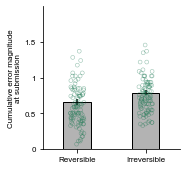

In [50]:
%matplotlib inline

plt.figure(figsize=(figsize,figsize))
plt.rcParams.update({'font.size': font_size})
    
plt.bar(1, np.mean(cum_error_UA_UNA[:,0]), yerr=np.std(cum_error_UA_UNA[:,0])/np.sqrt(100), color='0.7', edgecolor = 'k', width=0.4)
plt.bar(poz, np.mean(cum_error_UA_UNA[:,1]), yerr=np.std(cum_error_UA_UNA[:,1])/np.sqrt(100), color='0.7', edgecolor = 'k', width=0.4)

# Overlay individual dots as open circles
jitter1 = np.random.uniform(-0.1, 0.1, len(cum_error_UA_UNA[:,0]))
jitter2 = np.random.uniform(-0.1, 0.1, len(cum_error_UA_UNA[:,1]))
plt.scatter(1 + jitter1, cum_error_UA_UNA[:,0], facecolors='none', edgecolors='#1F7A55', s=15, alpha=0.5, zorder=3, linewidths=0.5)
plt.scatter(poz + jitter2, cum_error_UA_UNA[:,1], facecolors='none', edgecolors='#1F7A55', s=15, alpha=0.5, zorder=3, linewidths=0.5)

plt.xticks([1,poz], ['Reversible', 'Irreversible'])
plt.xlim([0.5,2.5])
plt.ylim([0,2])
plt.yticks(np.arange(0,2,0.5), ['0','0.5','1','1.5'])

sns.despine()
plt.tight_layout()
# y axis p(greedy choice) of the first move
plt.ylabel('Cumulative error magnitude\nat submission')
plt.savefig(out_dir + 'CumulativeErrorMagnitude_atsubmission' + save_mode, dpi=300, bbox_inches='tight')

## *first-move RT

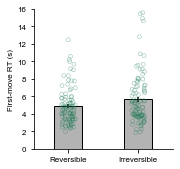

In [51]:
%matplotlib inline

first_rt_UA_UNA_ = first_rt_UA_UNA/1000

# bar plot for first RT
plt.figure(figsize=(figsize,figsize))
plt.rcParams.update({'font.size': font_size})

plt.bar(1, np.mean(first_rt_UA_UNA_[:,0]), yerr=np.std(first_rt_UA_UNA_[:,0])/np.sqrt(100), color='0.7', edgecolor = 'k', width=0.4)
plt.bar(poz, np.mean(first_rt_UA_UNA_[:,1]), yerr=np.std(first_rt_UA_UNA_[:,1])/np.sqrt(100), color='0.7', edgecolor = 'k', width=0.4)

# Overlay individual dots as open circles
jitter1 = np.random.uniform(-0.1, 0.1, len(first_rt_UA_UNA_[:,0]))
jitter2 = np.random.uniform(-0.1, 0.1, len(first_rt_UA_UNA_[:,1]))
plt.scatter(1 + jitter1, first_rt_UA_UNA_[:,0], facecolors='none', edgecolors='#1F7A55', s=15, alpha=0.5, zorder=3, linewidths=0.5)
plt.scatter(poz + jitter2, first_rt_UA_UNA_[:,1], facecolors='none', edgecolors='#1F7A55', s=15, alpha=0.5, zorder=3, linewidths=0.5)

plt.xticks([1,poz], ['Reversible', 'Irreversible'])
plt.xlim([0.5,2.5])
plt.ylim([0,16])
# plt.yticks(np.arange(0,10,2), ['0','2','4','6', '8'])

# remove top and right frame
sns.despine()

# save figure
plt.tight_layout()
plt.ylabel('First-move RT (s)')
plt.savefig(out_dir + '/bar_first_RT'+save_mode, dpi=300, bbox_inches='tight')

# save figure
plt.show()

## *cum error in the first attempt (matched puzzles, matched length)

In [ ]:
undo_level = data_choice_level[data_choice_level['condition']==1].copy().reset_index()
basic_level = data_choice_level[data_choice_level['condition']==0].copy().reset_index()

cumerror_first_tryout = []


for sub in range(100):

    dat_sbj  = sc_data_choice_level[sc_data_choice_level['subjects']==sub].sort_values(["puzzleID","index"])
    dat_sbj_undo  = undo_level[undo_level['subjects']==sub].sort_values(["puzzleID","index"])
    dat_sbj_basic  = basic_level[basic_level['subjects']==sub].sort_values(["puzzleID","index"])

    cumerror_first_tryout_puzzle = []

    for pzi in np.unique(sc_data_choice_level['puzzleID']):

        TS = map[pzi]

        dat_sbj_pzi = dat_sbj[dat_sbj['puzzleID'] == pzi].reset_index()
        dat_sbj_undo_pzi = dat_sbj_undo[dat_sbj_undo['puzzleID'] == pzi].reset_index()
        dat_sbj_basic_pzi = dat_sbj_basic[dat_sbj_basic['puzzleID'] == pzi].reset_index()

        # get distance from TS['xy'][0] to TS['xy'][1:]
        start = np.array(TS['xy'][0])
        # distance = [np.sum(np.sqrt((start - np.array(node))**2)) for node in TS['xy'][1:]]
        distance = [np.sum(np.sqrt((start - np.array(node))**2)) for node in TS['xy']]

        # find the index that is second shortest distance because the first shortest is goint back to itself
        idx = np.argsort(distance)[1]
        
        # if firstUndo is != 0
        if dat_sbj_undo_pzi['undo'].sum() == 0:
            cumerror_first_tryout_puzzle.append([np.nan, np.nan])
        else:
            idx_firstUndo = np.where(dat_sbj_undo_pzi['firstUndo']==1)[0]
            if len(idx_firstUndo) > 1:
                idx_firstUndo = idx_firstUndo[0]
                
            idx_submit = np.where(dat_sbj_basic_pzi['submit']==1)[0]
            if len(idx_submit) == 0:
                idx_submit = len(dat_sbj_basic_pzi)+1
                
            idx_ = min(idx_firstUndo-1, idx_submit-1)
            
            error_FT_UA = dat_sbj_undo_pzi['currMas'][0].item()-dat_sbj_undo_pzi['currMas'][idx_].item()            

            error_UNA = dat_sbj_basic_pzi['currMas'][0].item()-dat_sbj_basic_pzi['currMas'][idx_].item()
            
            cumerror_first_tryout_puzzle.append([error_FT_UA, error_UNA])
            
            # print([error_rate_FT_UA, error_rate_UNA])

    
    cumerror_first_tryout.append(np.nanmean(cumerror_first_tryout_puzzle, axis=0))
    # print(np.nanmean(cumerror_first_tryout_puzzle, axis=0))

cumerror_first_tryout = np.array(cumerror_first_tryout)


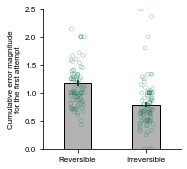

In [52]:
%matplotlib inline

idx_not_nan = ~np.isnan(cumerror_first_tryout).any(axis=1)

# bar plot for first RT
plt.figure(figsize=(figsize,figsize))
plt.rcParams.update({'font.size': font_size})

plt.bar(1, np.mean(cumerror_first_tryout[idx_not_nan,0]), yerr=np.std(cumerror_first_tryout[idx_not_nan,0])/np.sqrt(len(idx_not_nan)), color='0.7', edgecolor = 'k', width=0.4)
plt.bar(poz, np.mean(cumerror_first_tryout[idx_not_nan,1]), yerr=np.std(cumerror_first_tryout[idx_not_nan,1])/np.sqrt(len(idx_not_nan)), color='0.7', edgecolor = 'k', width=0.4)

# Overlay individual dots as open circles
jitter1 = np.random.uniform(-0.1, 0.1, len(cumerror_first_tryout[:,0]))
jitter2 = np.random.uniform(-0.1, 0.1, len(cumerror_first_tryout[:,1]))
plt.scatter(1 + jitter1, cumerror_first_tryout[:,0], facecolors='none', edgecolors='#1F7A55', s=15, alpha=0.5, zorder=3, linewidths=0.5)
plt.scatter(poz + jitter2, cumerror_first_tryout[:,1], facecolors='none', edgecolors='#1F7A55', s=15, alpha=0.5, zorder=3, linewidths=0.5)

plt.xticks([1,poz], ['Reversible', 'Irreversible'])
plt.xlim([0.5,2.5])
plt.ylim([0,2.5])

# remove top and right frame
sns.despine()
plt.tight_layout()
plt.ylabel('Cumulative error magnitude\nfor the first attempt')
# save figure
plt.savefig(out_dir + '/cumerror_firsttryout' + save_mode, dpi=300, bbox_inches='tight')
plt.show()

# *GLMM between conditions

In [ ]:
data_map = pd.DataFrame(columns=['undo_option_used', 'condition_UA', 'cum_error', 'cum_error_FT_OVL', 'first_error', 'firstmoveRT','subject', 'puzzle'])
data_all = pd.DataFrame(columns=['undo_option_used', 'condition_UA', 'cum_error', 'cum_error_FT_OVL', 'first_error', 'firstmoveRT','subject', 'puzzle'])
undo_level = data_choice_level[data_choice_level['condition']==1].copy().reset_index()
basic_level = data_choice_level[data_choice_level['condition']==0].copy().reset_index()

cum_error_UA_UNA = []
first_error_UA_UNA = []
first_RT = []
error_rate_first_tryout = []
cumerror_first_tryout = []


for sub in range(100):
    mas_gain_length = []
    # print('sub{}'.format(sub))
    dat_sbj_undo  = undo_level[undo_level['subjects']==sub].sort_values(["puzzleID","index"])
    dat_sbj_basic = basic_level[basic_level['subjects']==sub].sort_values(["puzzleID","index"])

    for pzi in np.unique(sc_data_choice_level['puzzleID']):
        
        dat_sbj_basic_pzi = dat_sbj_basic[dat_sbj_basic['puzzleID'] == pzi].reset_index()
        dat_sbj_undo_pzi = dat_sbj_undo[dat_sbj_undo['puzzleID'] == pzi].reset_index()

        if dat_sbj_undo_pzi['undo'].sum() == 0:
            error_rate_FT_UA = np.nan
            
            idx_submit = np.where(dat_sbj_basic_pzi['submit']==1)[0]
            if len(idx_submit) == 0:
                idx_submit = len(dat_sbj_basic_pzi)+1
            error_ = dat_sbj_basic_pzi['currMas'][0].item()-dat_sbj_basic_pzi['currMas'][idx_submit-1].item()
            len_ = np.abs(dat_sbj_basic_pzi['currNumCities'][0].item()-dat_sbj_basic_pzi['currNumCities'][idx_submit-1].item())
            error_rate_UNA = error_/len_
            
            cumerror_FT_UA = np.nan
            idx_ = idx_submit-1
            cumerror_UNA = dat_sbj_basic_pzi['currMas'][0].item()-dat_sbj_basic_pzi['currMas'][idx_].item()
            
        else:
        
            idx_firstUndo = np.where(dat_sbj_undo_pzi['firstUndo']==1)[0]
            if len(idx_firstUndo) > 1:
                idx_firstUndo = idx_firstUndo[0]
            error_ = dat_sbj_undo_pzi['currMas'][0].item()-dat_sbj_undo_pzi['currMas'][idx_firstUndo-1].item()
            len_ = np.abs(dat_sbj_undo_pzi['currNumCities'][0].item()-dat_sbj_undo_pzi['currNumCities'][idx_firstUndo-1].item())
            error_rate_FT_UA = error_/len_
                

            idx_submit = np.where(dat_sbj_basic_pzi['submit']==1)[0]
            if len(idx_submit) == 0:
                idx_submit = len(dat_sbj_basic_pzi)+1
            error_ = dat_sbj_basic_pzi['currMas'][0].item()-dat_sbj_basic_pzi['currMas'][idx_submit-1].item()
            len_ = np.abs(dat_sbj_basic_pzi['currNumCities'][0].item()-dat_sbj_basic_pzi['currNumCities'][idx_submit-1].item())
            error_rate_UNA = error_/len_
            
            
                
            idx_ = min(idx_firstUndo-1, idx_submit-1)
            
            cumerror_FT_UA = dat_sbj_undo_pzi['currMas'][0].item()-dat_sbj_undo_pzi['currMas'][idx_].item()            
            cumerror_UNA = dat_sbj_basic_pzi['currMas'][0].item()-dat_sbj_basic_pzi['currMas'][idx_].item()
        
        idx_not_undo = dat_sbj_undo_pzi[dat_sbj_undo_pzi['undo']==0].index
        data_all = pd.concat([data_all, pd.DataFrame([{
                                        'puzzle': pzi,
                                        'subject': sub,
                                        'condition_UA': 0, # undo not allowed
                                        'cum_error':np.abs(dat_sbj_basic_pzi['currMas'].iloc[-1] - dat_sbj_basic_pzi['currMas'].iloc[0]),
                                        'first_error':np.abs(dat_sbj_basic_pzi['currMas'].iloc[1] - dat_sbj_basic_pzi['currMas'].iloc[0]),
                                        'firstmoveRT':dat_sbj_basic_pzi['RT'].iloc[1]/1000,
                                        'undo_option_used':np.sign(dat_sbj_basic_pzi['undo'].sum()),
                                        'error_rate_FT_OVL':error_rate_UNA,
                                        'cum_error_FT_OVL':cumerror_UNA
                                    }])], ignore_index=True)
        data_all = pd.concat([data_all, pd.DataFrame([{
                                    'puzzle': pzi,
                                    'subject': sub,
                                    'condition_UA': 1, # undo allowed
                                    'cum_error':np.abs(dat_sbj_undo_pzi['currMas'].iloc[-1] - dat_sbj_undo_pzi['currMas'].iloc[0]),
                                    'first_error':np.abs(dat_sbj_undo_pzi['currMas'].iloc[1] - dat_sbj_undo_pzi['currMas'].iloc[0]),
                                    'firstmoveRT':dat_sbj_undo_pzi['RT'].iloc[1]/1000,
                                    'undo_option_used':np.sign(dat_sbj_undo_pzi['undo'].sum()),
                                    'error_rate_FT_OVL':error_rate_FT_UA,
                                    'cum_error_FT_OVL':cumerror_FT_UA
                                    }])], ignore_index=True)
        

In [10]:
data_all = data_all.copy()
data_all['subject'] = data_all['subject'].astype('int32')
data_all['puzzle'] = data_all['puzzle'].astype('int32')
data_all['condition_UA'] = data_all['condition_UA'].astype('int32')
data_all['undo_option_used'] = data_all['undo_option_used'].astype('int32')
data_all['cum_error'] = data_all['cum_error'].astype('float64')
data_all['cum_error_FT_OVL'] = data_all['cum_error_FT_OVL'].astype('float64')
data_all['first_error'] = data_all['first_error'].astype('float64')
data_all['firstmoveRT'] = data_all['firstmoveRT'].astype('float64')

# save data_all into a csv
data_all.to_csv(R_out_dir + '/dk_stats.csv', index=False)

## *Cumulative error magnitude at submission

In [14]:
%%R -i data_all

data_all$subject <- as.factor(data_all[,"subject"])
data_all$puzzle <- as.factor(data_all[,"puzzle"])
data_all$condition_UA <- as.factor(data_all[,"condition_UA"])

model = lme4::glmer(cum_error ~ condition_UA + (1|subject) + (1|puzzle), data=data_all, family=poisson)
model_full  = lme4::glmer(cum_error ~ condition_UA + (1+condition_UA|subject) + (1+condition_UA|puzzle), data=data_all, family=poisson)
summary(model)
summary(model_full)


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: cum_error ~ condition_UA + (1 + condition_UA | subject) + (1 +  
    condition_UA | puzzle)
   Data: data_all

     AIC      BIC   logLik deviance df.resid 
 18313.4  18370.4  -9148.7  18297.4     9192 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8392 -0.6386 -0.3619  0.4522  8.1741 

Random effects:
 Groups  Name          Variance Std.Dev. Corr 
 subject (Intercept)   0.13010  0.3607        
         condition_UA1 0.01848  0.1359   0.88 
 puzzle  (Intercept)   0.28438  0.5333        
         condition_UA1 0.03164  0.1779   -0.15
Number of obs: 9200, groups:  subject, 100; puzzle, 46

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -0.43352    0.08878  -4.883 1.04e-06 ***
condition_UA1 -0.25459    0.04237  -6.009 1.86e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlatio

## *Cum error mag in first-tryout in the undo allowed versus matched puzzle.

In [ ]:
%%R

# data_all$subject <- as.factor(data_all[,"subject"])
# data_all$puzzle <- as.factor(data_all[,"puzzle"])

model = lme4::glmer(cum_error_FT_OVL ~ condition_UA + (1|subject) + (1|puzzle), data=data_all, family=poisson)
model_full = lme4::glmer(cum_error_FT_OVL ~ condition_UA + (1+condition_UA|subject) + (1+condition_UA|puzzle), data=data_all, family=poisson)
summary(model)
summary(model_full)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: cum_error_FT_OVL ~ condition_UA + (1 | subject) + (1 | puzzle)
   Data: data_all

     AIC      BIC   logLik deviance df.resid 
 13124.3  13151.1  -6558.2  13116.3     6016 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9935 -0.6737 -0.1853  0.4306  8.0119 

Random effects:
 Groups  Name        Variance Std.Dev.
 subject (Intercept) 0.09733  0.3120  
 puzzle  (Intercept) 0.25343  0.5034  
Number of obs: 6020, groups:  subject, 100; puzzle, 46

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -0.42311    0.08271  -5.116 3.13e-07 ***
condition_UA1  0.34918    0.03317  10.528  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
conditn_UA1 -0.108


## first RT [check R file]

In [13]:
%%R

model = lme4::glmer(firstmoveRT ~ condition_UA + (1|subject) + (1|puzzle), data=data_all)

summary(model)


Linear mixed model fit by REML ['lmerMod']
Formula: firstmoveRT ~ condition_UA + (1 | subject) + (1 | puzzle)
   Data: data_all

REML criterion at convergence: 60067.4

Scaled residuals: 
   Min     1Q Median     3Q    Max 
-1.918 -0.315 -0.120  0.126 36.068 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept)  5.1808  2.2761  
 puzzle   (Intercept)  0.6321  0.7951  
 Residual             38.6986  6.2208  
Number of obs: 9200, groups:  subject, 100; puzzle, 46

Fixed effects:
              Estimate Std. Error t value
(Intercept)     5.6860     0.2720  20.907
condition_UA1  -0.8097     0.1297  -6.242

Correlation of Fixed Effects:
            (Intr)
conditn_UA1 -0.238


# *SUPP: Number of connected cities (map by map)

In [7]:
nct_cond_versus_cond = []

# for each subject
for sbj in range(100):
    # for puzzle
    dat_sbj_undo  = undo_level[undo_level['subjects']==sbj].sort_values(["puzzleID","index"])
    dat_sbj_basic = basic_level[basic_level['subjects']==sbj].sort_values(["puzzleID","index"])
    
    nct_sub = []

    for pzi in np.unique(sc_data_choice_level['puzzleID']):
        dat_sbj_undo_pzi = dat_sbj_undo[dat_sbj_undo['puzzleID'] == pzi].reset_index()
        dat_sbj_basic_pzi = dat_sbj_basic[dat_sbj_basic['puzzleID'] == pzi].reset_index()
        
        nct_sub.append([dat_sbj_basic_pzi['currNumCities'].iloc[-1], dat_sbj_undo_pzi['currNumCities'].iloc[-1]])
    
    nct_cond_versus_cond.append(nct_sub)
    
nct_cond_versus_cond = np.array(nct_cond_versus_cond)
        

In [11]:
nct_cond_versus_cond.shape


(100, 46, 2)

In [14]:
mean_cond = np.mean(nct_cond_versus_cond, axis=0)
sem_cond = np.std(nct_cond_versus_cond, axis=0) / np.sqrt(nct_cond_versus_cond.shape[0])
print(mean_cond.shape)
mean_cond

(46, 2)


array([[ 7.62,  7.67],
       [ 5.68,  5.63],
       [ 8.51,  8.69],
       [ 8.01,  8.26],
       [ 7.63,  7.74],
       [ 7.07,  7.2 ],
       [ 8.64,  8.7 ],
       [ 7.28,  7.35],
       [ 7.49,  7.63],
       [ 7.25,  7.58],
       [ 7.22,  7.5 ],
       [ 9.5 ,  9.64],
       [ 6.83,  6.92],
       [ 9.33,  9.33],
       [ 8.12,  8.25],
       [ 6.6 ,  6.95],
       [ 7.31,  7.54],
       [ 5.78,  5.93],
       [ 8.21,  8.14],
       [ 5.95,  6.34],
       [ 6.68,  7.2 ],
       [ 7.42,  7.57],
       [ 7.43,  7.64],
       [ 8.14,  8.4 ],
       [ 7.88,  7.99],
       [ 8.37,  8.01],
       [ 6.65,  7.27],
       [ 9.58,  9.72],
       [ 6.76,  7.1 ],
       [ 7.11,  7.28],
       [ 5.83,  6.07],
       [ 8.3 ,  8.39],
       [ 8.37,  8.53],
       [ 7.07,  7.18],
       [ 8.7 ,  8.61],
       [ 8.67,  8.8 ],
       [ 7.58,  7.61],
       [ 7.98,  8.1 ],
       [ 7.46,  7.61],
       [ 7.81,  7.99],
       [ 7.31,  7.43],
       [ 7.62,  7.8 ],
       [ 7.35,  7.65],
       [ 9.

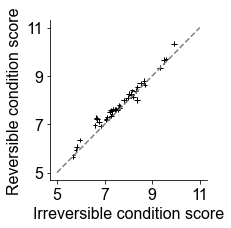

In [ ]:
%matplotlib inline
plt.rcParams.update({'font.size': font_size})

fig, ax = plt.subplots(figsize=(3, 3))

# scatter plot with x and y error bars that are sem_cond[:,0] and sem_cond[:,1]
ax.errorbar(mean_cond[:,0], mean_cond[:,1], 
            xerr=sem_cond[:,0], yerr=sem_cond[:,1], fmt='.', 
            color='black', ecolor='black', 
            elinewidth=1, capsize=0.1, markersize=0.1)

# plot the line y=x
ax.plot([5, 11], [5, 11], color='grey', linestyle='--')

# xticks ans yticks
ax.set_xticks([5, 7, 9, 11])
ax.set_yticks([5, 7, 9, 11])

# save figure
plt.tight_layout()
# xtitle ytitle
ax.set_xlabel('Irreversible condition score')
ax.set_ylabel('Reversible condition score')
plt.savefig(out_dir + 'num_cities_score_scatter' + save_mode, dpi=300, bbox_inches='tight')
